In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
data = {"PatientID": [1,2,3,4,5],
    "Age": [25,45,30,50,22],
    "Gender": ["M","F","M","F","M"],
    "Height": [170,160,175,155,180],
    "Weight": [65,70,80,68,75],
    "BP": [120,140,130,150,118],
    "Sugar": [90,160,110,180,85]}
df = pd.DataFrame(data)
df

,PatientID,Age,Gender,Height,Weight,BP,Sugar
0,1,25,M,170,65,120,90
1,2,45,F,160,70,140,160
2,3,30,M,175,80,130,110
3,4,50,F,155,68,150,180
4,5,22,M,180,75,118,85


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   PatientID  5 non-null      int64 
 1   Age        5 non-null      int64 
 2   Gender     5 non-null      object
 3   Height     5 non-null      int64 
 4   Weight     5 non-null      int64 
 5   BP         5 non-null      int64 
 6   Sugar      5 non-null      int64 
dtypes: int64(6), object(1)
memory usage: 412.0+ bytes


,PatientID,Age,Height,Weight,BP,Sugar
count,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000
mean,3.000000,34.400000,168.000000,71.60000,131.600000,125.000000
std,1.581139,12.421755,10.368221,5.94138,13.520355,42.720019
min,1.000000,22.000000,155.000000,65.00000,118.000000,85.000000
25%,2.000000,25.000000,160.000000,68.00000,120.000000,90.000000
50%,3.000000,30.000000,170.000000,70.00000,130.000000,110.000000
75%,4.000000,45.000000,175.000000,75.00000,140.000000,160.000000
max,5.000000,50.000000,180.000000,80.00000,150.000000,180.000000


In [6]:
df["Height_m"] = df["Height"] / 100
df["BMI"] = df["Weight"] / (df["Height_m"] ** 2)
df

,PatientID,Age,Gender,Height,Weight,BP,Sugar,Height_m,BMI
0,1,25,M,170,65,120,90,1.70,22.491349
1,2,45,F,160,70,140,160,1.60,27.343750
2,3,30,M,175,80,130,110,1.75,26.122449
3,4,50,F,155,68,150,180,1.55,28.303850
4,5,22,M,180,75,118,85,1.80,23.148148


In [7]:
def bmi_status(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"
df["BMI_Status"] = df["BMI"].apply(bmi_status)
df

,PatientID,Age,Gender,Height,Weight,BP,Sugar,Height_m,BMI,BMI_Status
0,1,25,M,170,65,120,90,1.70,22.491349,Normal
1,2,45,F,160,70,140,160,1.60,27.343750,Overweight
2,3,30,M,175,80,130,110,1.75,26.122449,Overweight
3,4,50,F,155,68,150,180,1.55,28.303850,Overweight
4,5,22,M,180,75,118,85,1.80,23.148148,Normal


In [8]:
df["BP_Status"] = df["BP"].apply(lambda x: "High" if x >= 140 else "Normal")
df["Sugar_Status"] = df["Sugar"].apply(lambda x: "High" if x >= 140 else "Normal")
df

,PatientID,Age,Gender,Height,Weight,BP,Sugar,Height_m,BMI,BMI_Status,BP_Status,Sugar_Status
0,1,25,M,170,65,120,90,1.70,22.491349,Normal,Normal,Normal
1,2,45,F,160,70,140,160,1.60,27.343750,Overweight,High,High
2,3,30,M,175,80,130,110,1.75,26.122449,Overweight,Normal,Normal
3,4,50,F,155,68,150,180,1.55,28.303850,Overweight,High,High
4,5,22,M,180,75,118,85,1.80,23.148148,Normal,Normal,Normal


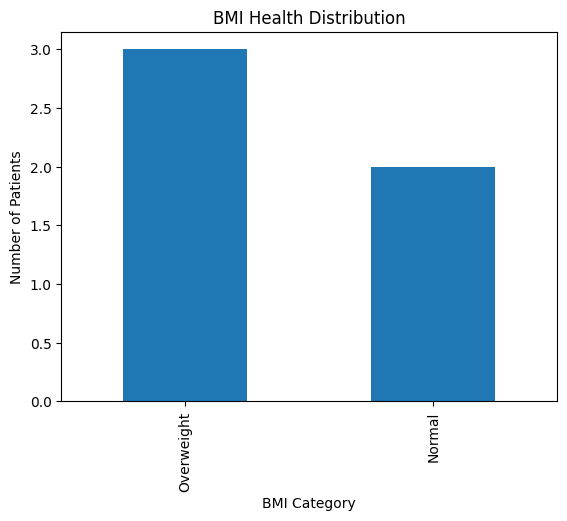

In [9]:
df["BMI_Status"].value_counts().plot(kind="bar")
plt.title("BMI Health Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Number of Patients")
plt.show()

In [10]:
df.to_csv("health_report.csv", index=False)